Shape: (918, 12)
Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Class balance: 55.3% positive


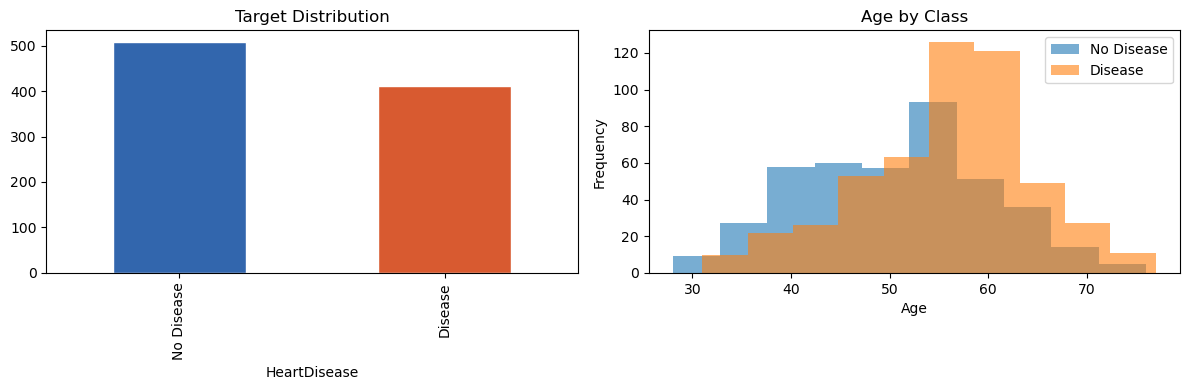

Best depth: 3  | Test acc: 0.8207


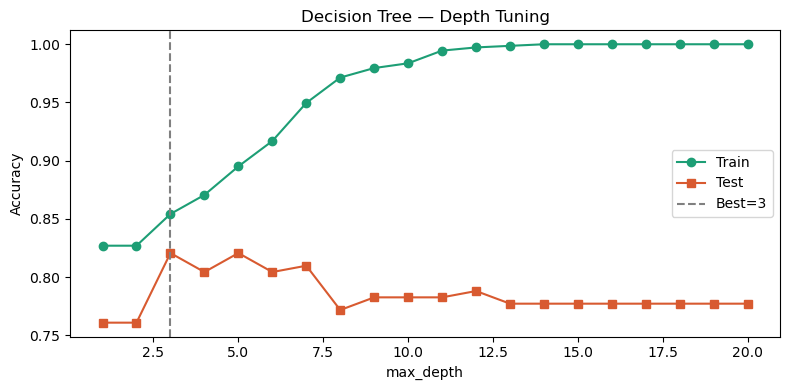

CV: [0.8478 0.8152 0.8098 0.8415 0.8197]  mean=0.8268  std=0.0151
DT  Acc=0.8207  AUC=0.8859


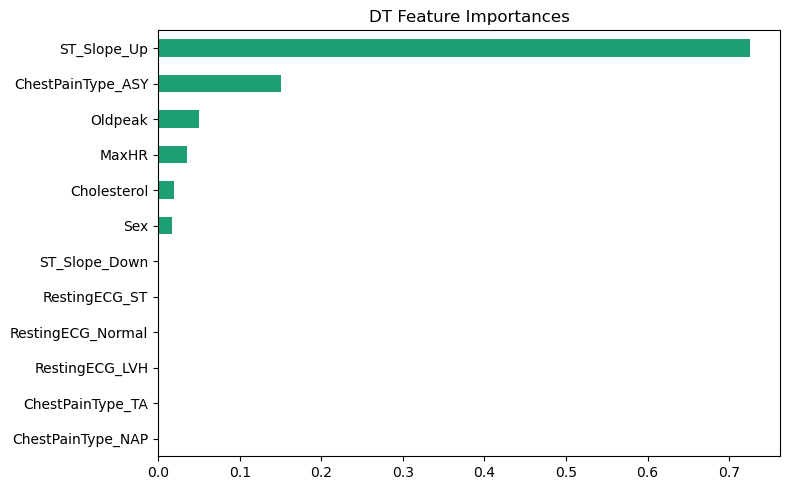

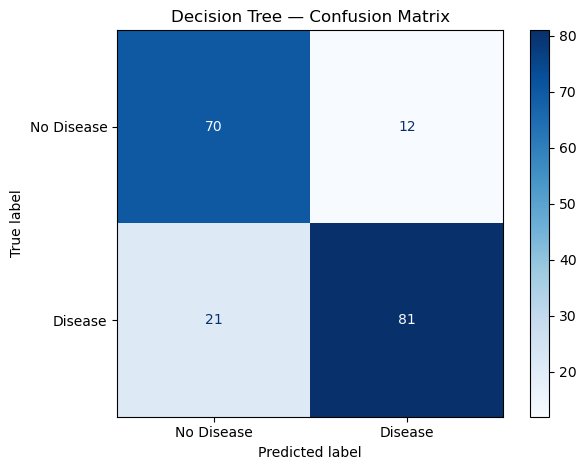

LR  Acc=0.8913  AUC=0.9271
Best C=0.0518  CV acc=0.8528
LogReg Acc=0.8859  AUC=0.9302
GNB Acc=0.8804  AUC=0.9070
              Model  Accuracy  AUC-ROC
  Linear Regression    0.8913   0.9271
Logistic Regression    0.8859   0.9302
        Naive Bayes    0.8804   0.9070
      Decision Tree    0.8207   0.8859


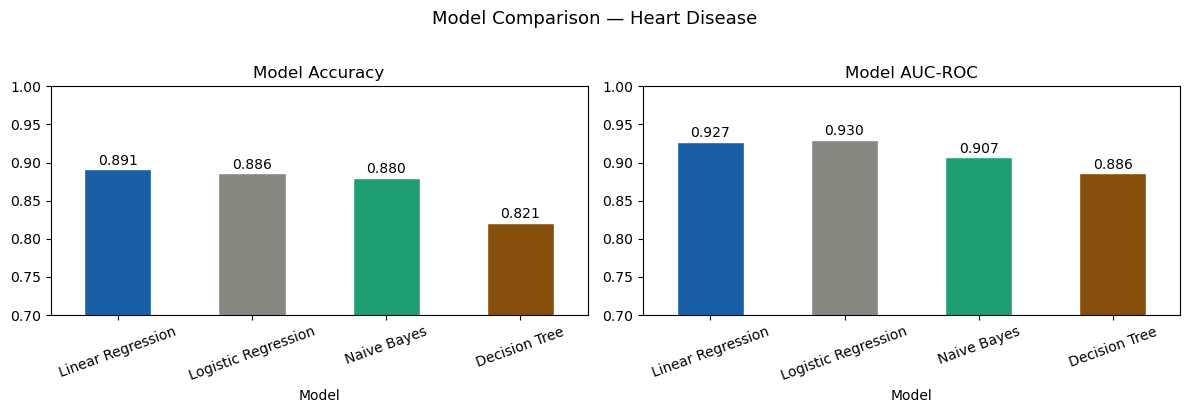

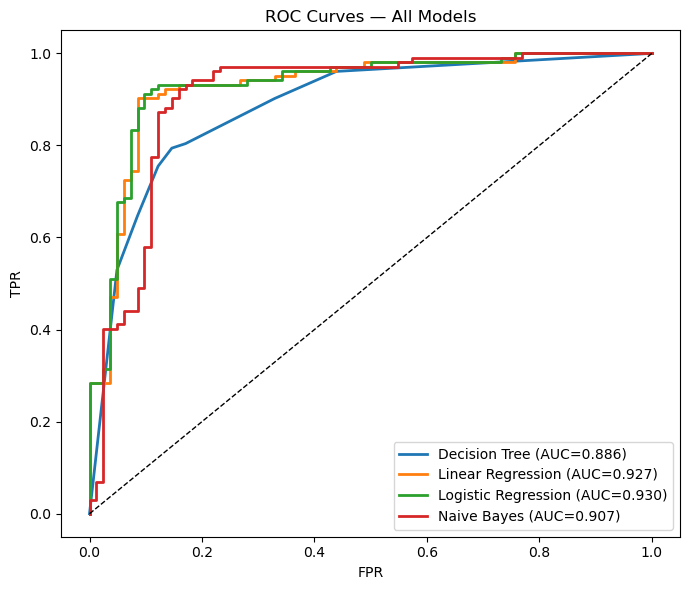

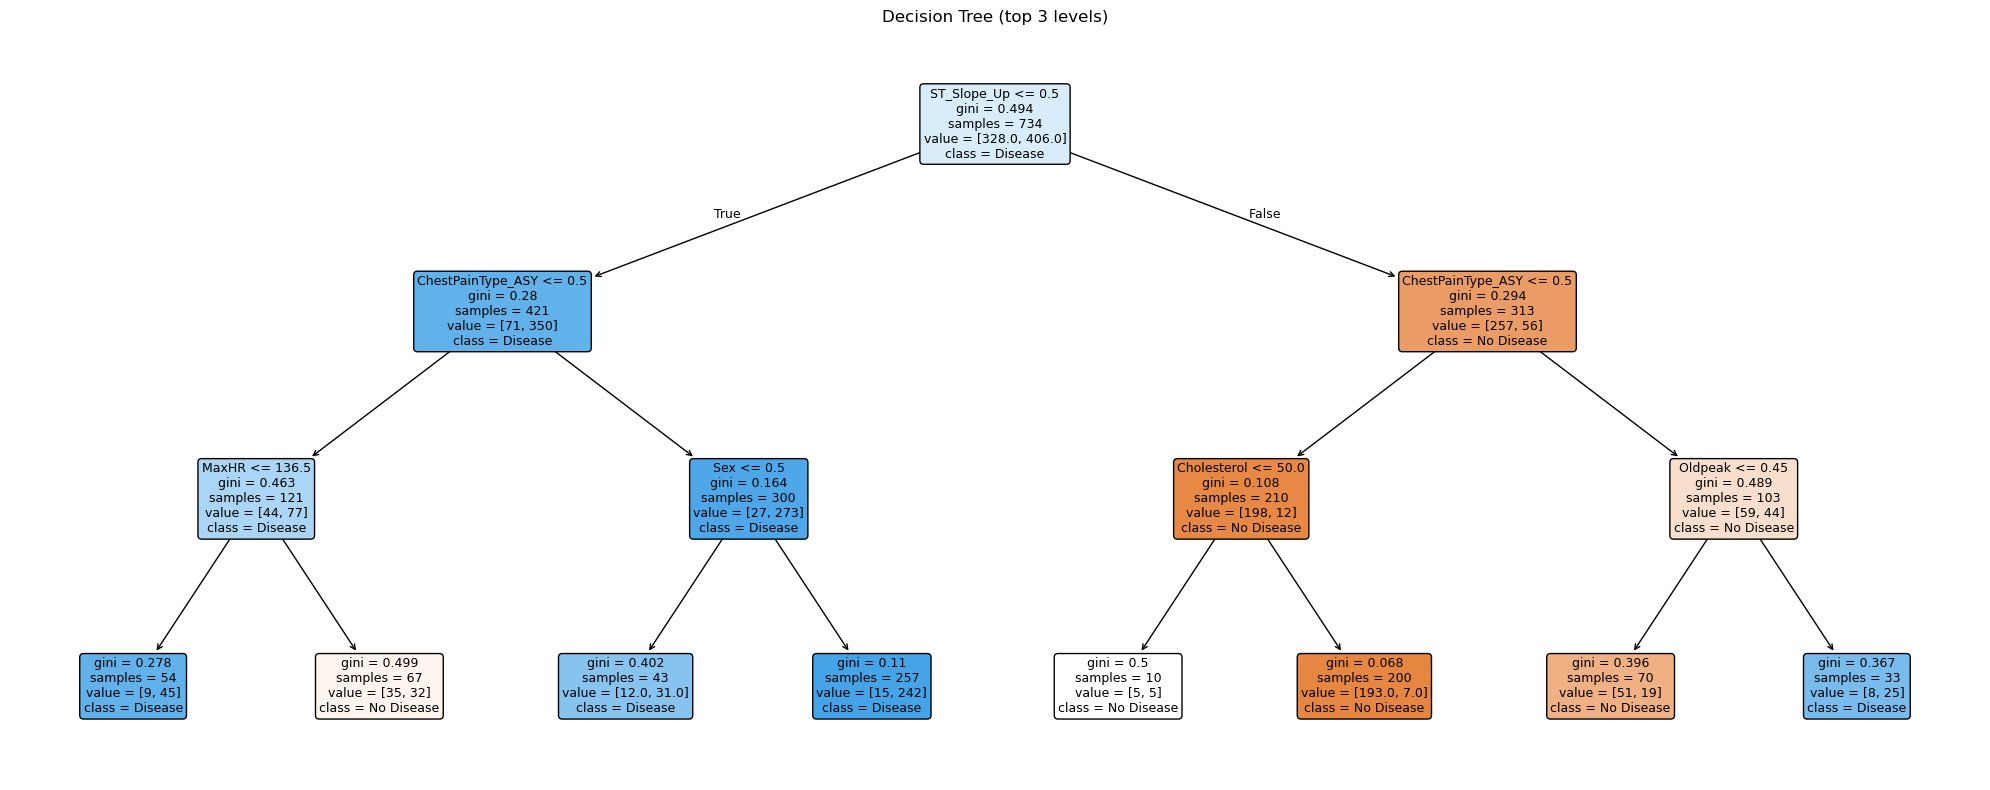

In [10]:
# Heart Disease Prediction — ML Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & EDA ──────────────────────────────────────────────────────────────
df = pd.read_csv('heart.csv')
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print(f"Class balance: {df['HeartDisease'].mean():.1%} positive")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['HeartDisease'].value_counts().plot(kind='bar', ax=axes[0], color=['#3266ad','#D85A30'], edgecolor='white')
axes[0].set(title='Target Distribution', xticklabels=['No Disease','Disease'])
for hd, lbl in [(0,'No Disease'),(1,'Disease')]:
    df[df['HeartDisease']==hd]['Age'].plot(kind='hist', alpha=0.6, ax=axes[1], label=lbl)
axes[1].set(title='Age by Class', xlabel='Age'); axes[1].legend()
plt.tight_layout(); plt.show()

# ── 2. Preprocessing ──────────────────────────────────────────────────────────
df['Sex']            = LabelEncoder().fit_transform(df['Sex'])
df['ExerciseAngina'] = LabelEncoder().fit_transform(df['ExerciseAngina'])
df = pd.get_dummies(df, columns=['ChestPainType','RestingECG','ST_Slope'])

X, y = df.drop('HeartDisease', axis=1), df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

# ── 3. Decision Tree ───────────────────────────────────────────────────────────
# Depth tuning
train_scores, test_scores = zip(*[
    (accuracy_score(y_train, DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train).predict(X_train)),
     accuracy_score(y_test,  DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train).predict(X_test)))
    for d in range(1, 21)
])
best_depth = int(np.argmax(test_scores)) + 1
print(f"Best depth: {best_depth}  | Test acc: {max(test_scores):.4f}")

plt.figure(figsize=(8,4))
plt.plot(range(1,21), train_scores, 'o-', label='Train', color='#1D9E75')
plt.plot(range(1,21), test_scores,  's-', label='Test',  color='#D85A30')
plt.axvline(best_depth, linestyle='--', color='gray', label=f'Best={best_depth}')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Decision Tree — Depth Tuning'); plt.legend(); plt.tight_layout(); plt.show()

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(DecisionTreeClassifier(max_depth=best_depth, random_state=42), X, y, cv=cv)
print(f"CV: {cv_scores.round(4)}  mean={cv_scores.mean():.4f}  std={cv_scores.std():.4f}")

# Final model
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train, y_train)
y_pred_dt, y_prob_dt = dt.predict(X_test), dt.predict_proba(X_test)[:,1]
print(f"DT  Acc={accuracy_score(y_test,y_pred_dt):.4f}  AUC={roc_auc_score(y_test,y_prob_dt):.4f}")

# Feature importances
pd.Series(dt.feature_importances_, index=X.columns).sort_values().tail(12).plot(
    kind='barh', color='#1D9E75', title='DT Feature Importances', figsize=(8,5))
plt.tight_layout(); plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['No Disease','Disease'], cmap='Blues')
plt.title('Decision Tree — Confusion Matrix'); plt.tight_layout(); plt.show()

# ── 4. Linear Regression (baseline) ───────────────────────────────────────────
lr = LinearRegression().fit(X_train_s, y_train)
y_raw_lr  = lr.predict(X_test_s)
y_pred_lr = (y_raw_lr >= 0.5).astype(int)
print(f"LR  Acc={accuracy_score(y_test,y_pred_lr):.4f}  AUC={roc_auc_score(y_test,y_raw_lr):.4f}")

# ── 5. Logistic Regression ─────────────────────────────────────────────────────
logreg_cv = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                         {'C': np.logspace(-5, 8, 15)}, cv=5, scoring='accuracy', n_jobs=-1)
logreg_cv.fit(X_train_s, y_train)
best_C = logreg_cv.best_params_['C']
print(f"Best C={best_C:.4f}  CV acc={logreg_cv.best_score_:.4f}")

log_reg = LogisticRegression(max_iter=1000, C=best_C, random_state=42).fit(X_train_s, y_train)
y_pred_log, y_prob_log = log_reg.predict(X_test_s), log_reg.predict_proba(X_test_s)[:,1]
print(f"LogReg Acc={accuracy_score(y_test,y_pred_log):.4f}  AUC={roc_auc_score(y_test,y_prob_log):.4f}")

# ── 6. Naive Bayes ─────────────────────────────────────────────────────────────
gnb = GaussianNB().fit(X_train, y_train)
y_pred_gnb, y_prob_gnb = gnb.predict(X_test), gnb.predict_proba(X_test)[:,1]
print(f"GNB Acc={accuracy_score(y_test,y_pred_gnb):.4f}  AUC={roc_auc_score(y_test,y_prob_gnb):.4f}")

# ── 7. Model Comparison ────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model':    ['Decision Tree','Linear Regression','Logistic Regression','Naive Bayes'],
    'Accuracy': [accuracy_score(y_test, p) for p in [y_pred_dt, y_pred_lr, y_pred_log, y_pred_gnb]],
    'AUC-ROC':  [roc_auc_score(y_test, p) for p in [y_prob_dt, y_raw_lr,  y_prob_log, y_prob_gnb]],
}).sort_values('Accuracy', ascending=False).round(4)
print(results_df.to_string(index=False))

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(12,4))
colors = ['#185FA5','#888780','#1D9E75','#854F0B']
for ax, metric in zip(axes, ['Accuracy','AUC-ROC']):
    results_df.plot(kind='bar', x='Model', y=metric, ax=ax, color=colors, legend=False, edgecolor='white')
    ax.set(title=f'Model {metric}', ylim=(0.70,1.0)); ax.tick_params(axis='x', rotation=20)
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}', (bar.get_x()+bar.get_width()/2, bar.get_height()+0.002),
                    ha='center', va='bottom', fontsize=10)
plt.suptitle('Model Comparison — Heart Disease', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ROC curves
plt.figure(figsize=(7,6))
for name, prob in [('Decision Tree',y_prob_dt),('Linear Regression',y_raw_lr),
                   ('Logistic Regression',y_prob_log),('Naive Bayes',y_prob_gnb)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(y_test,prob):.3f})')
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves — All Models')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.title('Decision Tree (top 3 levels)')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()